<a href="https://colab.research.google.com/github/eehujnihs21-stack/2555037/blob/main/2555037%EC%8B%A0%EC%A3%BC%ED%9D%AC_0320.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import glob

In [2]:
def load_data_from_api():
    # 로켓 발사 정보 API 주소
    url = "https://ll.thespacedevs.com/2.0.0/launch/upcoming"

    # 1. 데이터를 저장할 폴더(data) 생성
    os.makedirs("data", exist_ok=True)

    try:
        # 2. API 호출 (인터넷에서 데이터 가져오기)
        response = requests.get(url)
        response.raise_for_status() # 인터넷 연결 에러 체크
        data = response.json()

        # 3. 가져온 데이터를 json 파일로 저장
        json_path = os.path.join("data", "launches.json")
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=4)

        print("✅ [단계 1 성공] 데이터 수집 및 data/launches.json 저장 완료!")

        # 4. 판다스 데이터프레임으로 변환해서 화면에 보여주기
        df = pd.DataFrame(data.get('results', []))
        return df

    except requests.exceptions.RequestException as e:
        print(f"❌ 네트워크 오류 발생: {e}")
        return pd.DataFrame()

# 함수 실행해서 결과 확인하기
df_launch = load_data_from_api()
df_launch.head(3) # 상위 3개 데이터 출력

✅ [단계 1 성공] 데이터 수집 및 data/launches.json 저장 완료!


,id,url,launch_library_id,slug,name,status,net,window_end,window_start,inhold,...,failreason,hashtag,launch_service_provider,rocket,mission,pad,webcast_live,image,infographic,program
0,384fb817-2a18-46ec-b294-613c08ecea52,https://ll.thespacedevs.com/2.0.0/launch/384fb...,None,falcon-9-block-5-starlink-group-10-53,Falcon 9 Block 5 | Starlink Group 10-53,"{'id': 1, 'name': 'Go'}",2026-05-29T11:52:00Z,2026-05-29T15:52:00Z,2026-05-29T11:52:00Z,False,...,,None,"{'id': 121, 'url': 'https://ll.thespacedevs.co...","{'id': 9025, 'configuration': {'id': 164, 'lau...","{'id': 7620, 'launch_library_id': None, 'name'...","{'id': 80, 'url': 'https://ll.thespacedevs.com...",False,https://thespacedevs-prod.nyc3.digitaloceanspa...,None,"[{'id': 25, 'url': 'https://ll.thespacedevs.co..."
1,ff0a6a32-6513-4e85-9fd8-a2d022add74d,https://ll.thespacedevs.com/2.0.0/launch/ff0a6...,None,atlas-v-551-amazon-leo-la-07,Atlas V 551 | Amazon Leo (LA-07),"{'id': 1, 'name': 'Go'}",2026-05-29T23:33:00Z,2026-05-30T00:02:00Z,2026-05-29T23:33:00Z,False,...,,None,"{'id': 124, 'url': 'https://ll.thespacedevs.co...","{'id': 180, 'configuration': {'id': 27, 'launc...","{'id': 5999, 'launch_library_id': None, 'name'...","{'id': 29, 'url': 'https://ll.thespacedevs.com...",False,https://thespacedevs-prod.nyc3.digitaloceanspa...,None,"[{'id': 27, 'url': 'https://ll.thespacedevs.co..."
2,a7341350-789e-4f61-99a4-a61ebc40c05b,https://ll.thespacedevs.com/2.0.0/launch/a7341...,None,falcon-9-block-5-starlink-group-17-41,Falcon 9 Block 5 | Starlink Group 17-41,"{'id': 1, 'name': 'Go'}",2026-05-30T14:00:00Z,2026-05-30T18:00:00Z,2026-05-30T14:00:00Z,False,...,,None,"{'id': 121, 'url': 'https://ll.thespacedevs.co...","{'id': 9023, 'configuration': {'id': 164, 'lau...","{'id': 7618, 'launch_library_id': None, 'name'...","{'id': 16, 'url': 'https://ll.thespacedevs.com...",False,https://thespacedevs-prod.nyc3.digitaloceanspa...,None,"[{'id': 25, 'url': 'https://ll.thespacedevs.co..."


In [3]:
def get_pictures():
    json_path = os.path.join("data", "launches.json")

    # JSON 파일이 잘 있는지 확인
    if not os.path.exists(json_path):
        print("❌ JSON 파일이 없습니다. 1번 단계를 먼저 실행하세요.")
        return

    # JSON 파일 읽어오기
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # 이미지를 저장할 폴더(image) 생성
    os.makedirs("image", exist_ok=True)

    launches = data.get('results', [])

    print("🚀 이미지 다운로드를 시작합니다...")
    for idx, launch in enumerate(launches):
        image_url = launch.get('image') # 이미지 주소 쏙 빼오기

        # 이미지가 없는 경우 예외 처리
        if not image_url:
            print(f"  [-] [{idx}] 이미지 URL이 없습니다. 패스!")
            continue

        try:
            # 이미지 다운로드 시도
            img_response = requests.get(image_url, timeout=10)
            img_response.raise_for_status()

            # 파일 확장자 정하기 (png, jpg 등)
            ext = image_url.split('.')[-1].split('?')[0]
            if len(ext) > 4 or not ext:
                ext = "jpg"

            # 파일 이름 정해서 저장 (예: launch_0.jpg)
            filename = f"launch_{idx}.{ext}"
            save_path = os.path.join("image", filename)

            with open(save_path, "wb") as img_file:
                img_file.write(img_response.content)
            print(f"  [+] [{idx}] 다운로드 완료: {filename}")

        except requests.exceptions.RequestException as e:
            print(f"  [x] [{idx}] 다운로드 실패 (주소 오류): {e}")

    print("✅ [단계 2 성공] 이미지 다운로드 프로세스 완료!")

# 함수 실행
get_pictures()

🚀 이미지 다운로드를 시작합니다...
  [+] [0] 다운로드 완료: launch_0.png
  [+] [1] 다운로드 완료: launch_1.jpeg
  [+] [2] 다운로드 완료: launch_2.png
  [+] [3] 다운로드 완료: launch_3.jpeg
  [+] [4] 다운로드 완료: launch_4.png
  [+] [5] 다운로드 완료: launch_5.png
  [+] [6] 다운로드 완료: launch_6.png
  [+] [7] 다운로드 완료: launch_7.jpeg
  [+] [8] 다운로드 완료: launch_8.jpeg
  [+] [9] 다운로드 완료: launch_9.jpg
✅ [단계 2 성공] 이미지 다운로드 프로세스 완료!


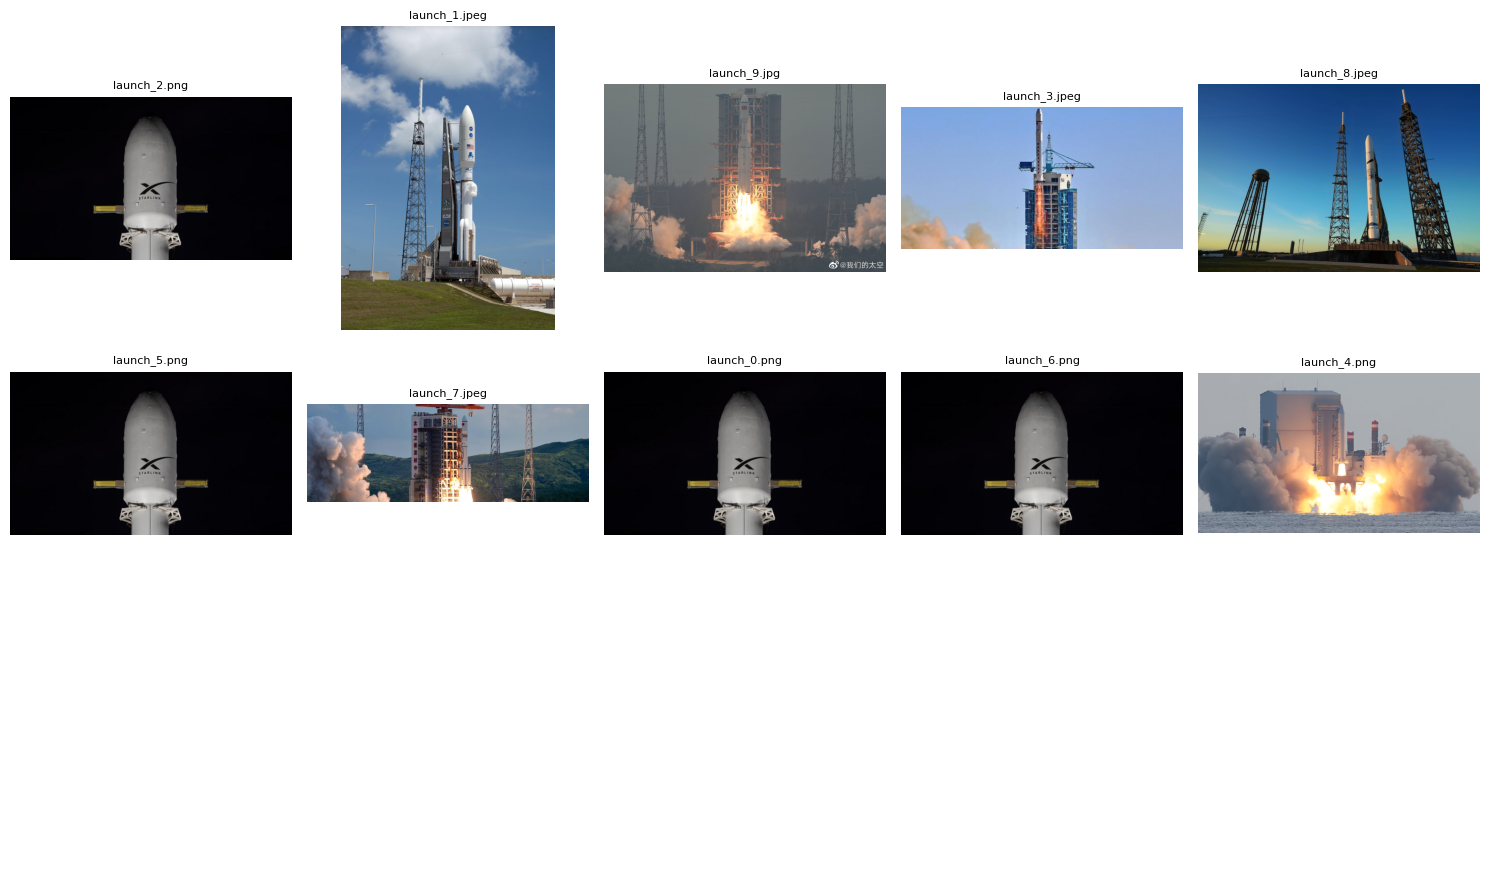

In [4]:
# image 폴더 안에 있는 모든 파일 목록 가져오기
image_files = glob.glob("image/*")

if not image_files:
    print("❌ 시각화할 이미지가 없습니다. image 폴더를 확인하세요.")
else:
    # 3행 5열(총 15개)로 사진을 보여줄 틀 만들기
    fig, axes = plt.subplots(3, 5, figsize=(15, 9))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < len(image_files):
            img = Image.open(image_files[i])
            ax.imshow(img)
            ax.set_title(os.path.basename(image_files[i]), fontsize=8)
            ax.axis('off') # 격자 테두리 숨기기
        else:
            ax.axis('off') # 남는 칸은 빈칸으로 두기

    plt.tight_layout()
    plt.show()

In [5]:
# 1. Extract (추출): 인터넷 주소에서 타이타닉 CSV 데이터 읽어오기
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_titanic = pd.read_csv(titanic_url)

# 2. Transform (변환): 나이(Age) 데이터의 빈칸을 중간값으로 채워주는 간단한 전처리
df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].median())

# 3. Load (저장): 전처리가 끝난 데이터를 data 폴더에 새 CSV 파일로 저장
df_titanic.to_csv("data/transformed_titanic.csv", index=False)

print("✅ [단계 4 성공] 타이타닉 데이터 ETL 완료!")
df_titanic.head(5) # 처리된 데이터 상위 5개 확인

✅ [단계 4 성공] 타이타닉 데이터 ETL 완료!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
